In [1]:
import pandas as pd

First we check to see if the `IUCR`, `Description` and `Primary Type`, `FBI Code` columns are the same.

In [2]:
chicago_crime_df = pd.read_csv('chicago_crime.csv',
                               dtype = {
                                   "ID": "float64",
                                   "Case Number": "string",
                                   "Date": "string",
                                   "Block": "string",
                                   "IUCR": "string",
                                   "Primary Type": "string",
                                   "Description": "string",
                                   "Location Description": "string",
                                   "Arrest": "object",
                                   "Domestic": "object",
                                   "Beat": "float32",
                                   "District": "float32",
                                   "Ward": "float32",
                                   "Community Area": "float32",
                                   "FBI Code": "string",
                                   "X Coordinate": "float32",
                                   "Y Coordinate": "float32",
                                   "Year": "float32",
                                   "Updated On": "string",
                                   "Latitude": "float32",
                                   "Longitude": "float32",
                                   "Location": "string"
                               },
                               low_memory = False
                )

In [3]:
print(chicago_crime_df.groupby('IUCR')['Description'].nunique().sum()  == len(chicago_crime_df.groupby('IUCR')['Description'].nunique()))
print(chicago_crime_df.groupby('Primary Type')['FBI Code'].nunique().sum() == len(chicago_crime_df.groupby('Primary Type')['FBI Code'].nunique()))

False
False


In [4]:
chicago_crime_df.groupby('IUCR')['Description'].nunique().reset_index()
chicago_crime_df[
    (chicago_crime_df['IUCR'] == "5121") | (chicago_crime_df['IUCR'] == "5122") | (chicago_crime_df['IUCR'] == "0261")][['IUCR', 'Description']].drop_duplicates()

,IUCR,Description
9630,0261,AGGRAVATED - HANDGUN
115331,5121,ARSONIST - ANNUAL REGISTRATION
285609,5122,ARSONIST - FAIL TO REGISTER NEW ADDRESS
1467014,5121,ARSONIST: ANNUAL REGISTRATION
1497810,0261,AGGRAVATED: HANDGUN
1842688,5122,ARSONIST: FAIL TO REGISTER NEW ADDRESS


In [5]:
chicago_crime_df.groupby('FBI Code')['Primary Type'].nunique()
chicago_crime_df[chicago_crime_df['FBI Code'] == "26"].drop_duplicates().head(3)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4,14160497.0,JK209847,04/08/2026 12:00:00 AM,017XX W DEVON AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,false,false,...,40.0,77.0,26,1163295.0,1942550.0,2026.0,04/15/2026 03:43:00 PM,41.998001,-87.674652,"(41.998000526, -87.674648345)"
19,14160328.0,JK209599,04/07/2026 11:13:00 PM,076XX S CLYDE AVE,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,false,true,...,8.0,43.0,26,1191531.0,1854654.0,2026.0,04/15/2026 03:43:00 PM,41.756168,-87.573639,"(41.756168716, -87.573641687)"
27,14160306.0,JK209560,04/07/2026 10:35:00 PM,0000X W 111TH ST,1330,CRIMINAL TRESPASS,TO LAND,GAS STATION,true,false,...,9.0,49.0,26,1178040.0,1831365.0,2026.0,04/15/2026 03:43:00 PM,41.692577,-87.623787,"(41.692576964, -87.623786349)"


Drop the columns that provide not much information for our models.

In [6]:
df = chicago_crime_df.drop(columns = ['ID', 'Case Number', 'Block', 'Description', 'Ward', 'Updated On', 'Location'])

Check for Null values

In [7]:
df.isna().sum()

Date                         0
IUCR                         0
Primary Type                 0
Location Description     15886
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Community Area          613727
FBI Code                     0
X Coordinate             96353
Y Coordinate             96353
Year                         0
Latitude                 96353
Longitude                96353
dtype: int64

Same number for lat/long and X/Y columns. Maybe same rows?

In [8]:
(df['X Coordinate'].isna() & df['Y Coordinate'].isna() & df['Latitude'].isna() & df['Longitude'].isna()).sum()

df = df[df['X Coordinate'].notna()]

df.isna().sum()

Date                         0
IUCR                         0
Primary Type                 0
Location Description     10384
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Community Area          604523
FBI Code                     0
X Coordinate                 0
Y Coordinate                 0
Year                         0
Latitude                     0
Longitude                    0
dtype: int64

<Axes: >

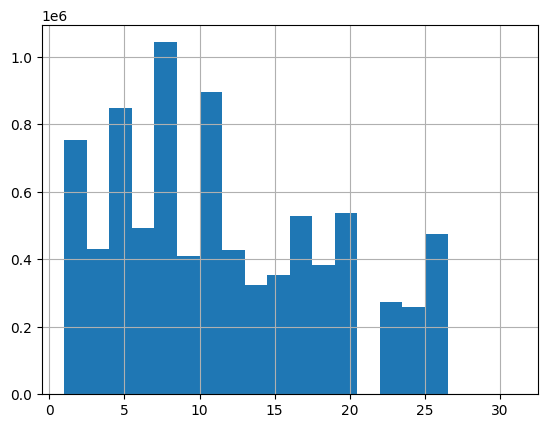

In [12]:
df['District'].hist(bins = 20)

Skewed Distribution. Fill with median.

In [13]:
df['District_missing'] = df['District'].isna().astype(int)
df['District'] = df['District'].fillna(df['District'].median())

In [14]:
df.rename(columns = {'District_missing': "District Missing"}, inplace = True)

df['Location Description Missing'] = df['Location Description'].isna().astype(int)
df['Location Description'] = df['Location Description'].fillna("Unknown")

[Text(0, 0, ''),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, ''),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, ''),
 Text(14, 0, ''),
 Text(15, 0, ''),
 Text(16, 0, ''),
 Text(17, 0, ''),
 Text(18, 0, ''),
 Text(19, 0, ''),
 Text(20, 0, ''),
 Text(21, 0, ''),
 Text(22, 0, ''),
 Text(23, 0, ''),
 Text(24, 0, ''),
 Text(25, 0, ''),
 Text(26, 0, ''),
 Text(27, 0, ''),
 Text(28, 0, ''),
 Text(29, 0, ''),
 Text(30, 0, ''),
 Text(31, 0, ''),
 Text(32, 0, ''),
 Text(33, 0, ''),
 Text(34, 0, ''),
 Text(35, 0, ''),
 Text(36, 0, ''),
 Text(37, 0, ''),
 Text(38, 0, ''),
 Text(39, 0, ''),
 Text(40, 0, ''),
 Text(41, 0, ''),
 Text(42, 0, ''),
 Text(43, 0, ''),
 Text(44, 0, ''),
 Text(45, 0, ''),
 Text(46, 0, ''),
 Text(47, 0, ''),
 Text(48, 0, ''),
 Text(49, 0, ''),
 Text(50, 0, ''),
 Text(51, 0, ''),
 Text(52, 0, ''),
 Text(53, 0, ''),
 Text(54, 0, ''),
 Text(55, 0, ''),
 T

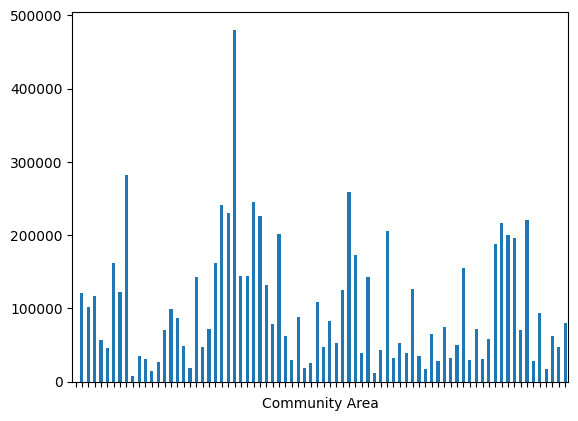

In [25]:
ax = df['Community Area'].value_counts().sort_index().plot.bar()
ax.set_xticklabels([])

In [27]:
df["Community Area Missing"] = df["Community Area"].isna().astype(int)
df["Community Area"] =  df["Community Area"].fillna(df["Community Area"].mode()[0])
df["Community Area"] = df["Community Area"].astype("int16")

In [28]:
df.isna().sum()

Date                            0
IUCR                            0
Primary Type                    0
Location Description            0
Arrest                          0
Domestic                        0
Beat                            0
District                        0
Community Area                  0
FBI Code                        0
X Coordinate                    0
Y Coordinate                    0
Year                            0
Latitude                        0
Longitude                       0
District Missing                0
Location Description Missing    0
District Missing                0
Community Area Missing          0
dtype: int64